In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Load the data
df = pd.read_csv('../data/insurance_data.csv')

print("=" * 50)
print("DATA LOADED SUCCESSFULLY")
print("=" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

DATA LOADED SUCCESSFULLY
Dataset shape: (10000, 21)
Number of rows: 10000
Number of columns: 21


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [27]:
# Check data types
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(df.columns.tolist())

DATA TYPES
CustomerID                 str
Age                      int64
Gender                     str
Province                   str
VehicleType                str
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType                  str
AutoMake                   str
VehicleModel               str
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate            str
dtype: object

COLUMN NAMES
['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate']


In [28]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)

print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in the dataset.")

# Document handling strategy
print("\n" + "=" * 50)
print("HANDLING STRATEGY")
print("=" * 50)
print("Columns with >50% missing values will be dropped.")
print("Columns with <5% missing values will have rows dropped.")
print("Columns with 5-50% missing values will be imputed with median/mode.")

MISSING VALUES REPORT
No missing values found in the dataset.

HANDLING STRATEGY
Columns with >50% missing values will be dropped.
Columns with <5% missing values will have rows dropped.
Columns with 5-50% missing values will be imputed with median/mode.


In [29]:
# Descriptive statistics for numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("=" * 50)
print("DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("=" * 50)
print(df[numeric_cols].describe())

DESCRIPTIVE STATISTICS - NUMERICAL FEATURES
                Age  AnnualIncome     RiskScore  AnnualPremium    Deductible  \
count  10000.000000   10000.00000  10000.000000   10000.000000  10000.000000   
mean      46.683500   79201.97390     58.140000    2488.127900    751.700000   
std       16.717963   33039.93977     14.267486     735.674491    500.509401   
min       18.000000   17202.00000     15.000000     951.000000    250.000000   
25%       32.000000   56105.00000     48.000000    2028.000000    500.000000   
50%       46.000000   72942.00000     57.000000    2307.000000    500.000000   
75%       61.000000   95092.00000     67.000000    2676.000000   1000.000000   
max       75.000000  376916.00000     95.000000    5105.000000   2000.000000   

                NCD    PastClaims   ClaimAmount  TotalPremium   TotalClaims  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      20.935000      1.064200   1314.188500   2488.127900   1314.188500  

In [30]:
# Check categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("=" * 50)
print("CATEGORICAL COLUMNS")
print("=" * 50)
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(3))

CATEGORICAL COLUMNS

CustomerID: 10000 unique values
CustomerID
AC-100000    1
AC-100001    1
AC-100002    1
Name: count, dtype: int64

Gender: 2 unique values
Gender
Female    5138
Male      4862
Name: count, dtype: int64

Province: 5 unique values
Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Name: count, dtype: int64

VehicleType: 4 unique values
VehicleType
Sedan        3992
SUV          3000
Hatchback    2036
Name: count, dtype: int64

CoverType: 3 unique values
CoverType
Comprehensive               4720
Third Party Fire & Theft    3453
Third Party Only            1827
Name: count, dtype: int64

AutoMake: 6 unique values
AutoMake
Toyota     3281
Hyundai    3076
Suzuki     1708
Name: count, dtype: int64

VehicleModel: 12 unique values
VehicleModel
Elantra    1389
Corolla    1324
620        1279
Name: count, dtype: int64

TransactionDate: 546 unique values
TransactionDate
2025-04-03    35
2024-02-24    32
2025-06-09    31
Name: count, dtype: int64


In [31]:
# Loss Ratio = TotalClaims / TotalPremium
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['LossRatio'] = df['LossRatio'].replace([np.inf, -np.inf], np.nan)

print("=" * 50)
print("LOSS RATIO ANALYSIS")
print("=" * 50)
print(f"Overall Portfolio Loss Ratio: {df['LossRatio'].mean():.4f}")
print(f"Median Loss Ratio: {df['LossRatio'].median():.4f}")
print(f"Standard Deviation: {df['LossRatio'].std():.4f}")

LOSS RATIO ANALYSIS
Overall Portfolio Loss Ratio: 0.4428
Median Loss Ratio: 0.0000
Standard Deviation: 1.2528


LOSS RATIO BY PROVINCE
Province
Somali         0.523516
Oromia         0.452680
Tigray         0.438639
Addis Ababa    0.436347
Amhara         0.395941
Name: LossRatio, dtype: float64


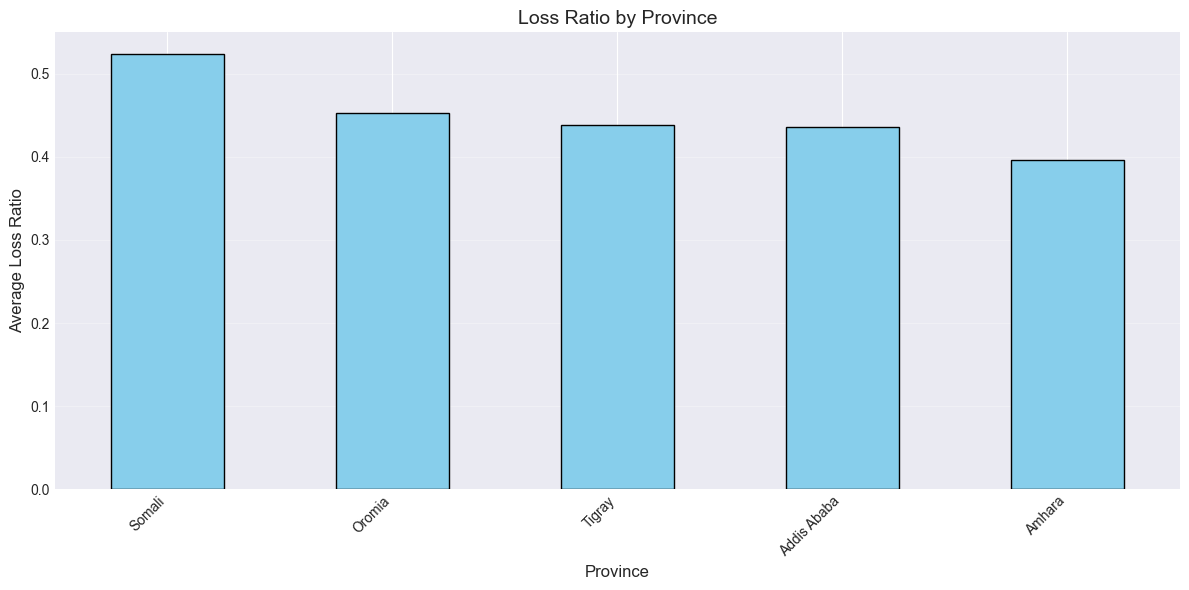

In [32]:
# Loss Ratio by Province
province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)

print("=" * 50)
print("LOSS RATIO BY PROVINCE")
print("=" * 50)
print(province_loss)

# Plot
plt.figure(figsize=(12, 6))
province_loss.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Loss Ratio by Province', fontsize=14)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Loss Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

LOSS RATIO BY GENDER
Gender
Female    0.447351
Male      0.437929
Name: LossRatio, dtype: float64


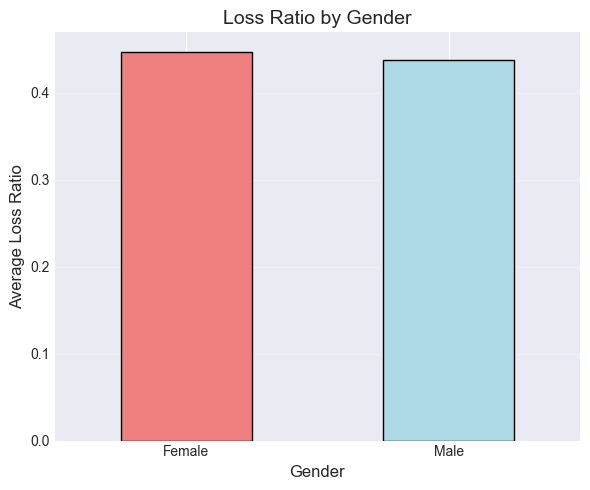

In [33]:
# Loss Ratio by Gender
gender_loss = df.groupby('Gender')['LossRatio'].mean()

print("=" * 50)
print("LOSS RATIO BY GENDER")
print("=" * 50)
print(gender_loss)

# Plot
plt.figure(figsize=(6, 5))
gender_loss.plot(kind='bar', color=['lightcoral', 'lightblue'], edgecolor='black')
plt.title('Loss Ratio by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Loss Ratio', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

LOSS RATIO BY VEHICLE TYPE
VehicleType
Luxury       0.803672
SUV          0.499749
Hatchback    0.370846
Sedan        0.348758
Name: LossRatio, dtype: float64


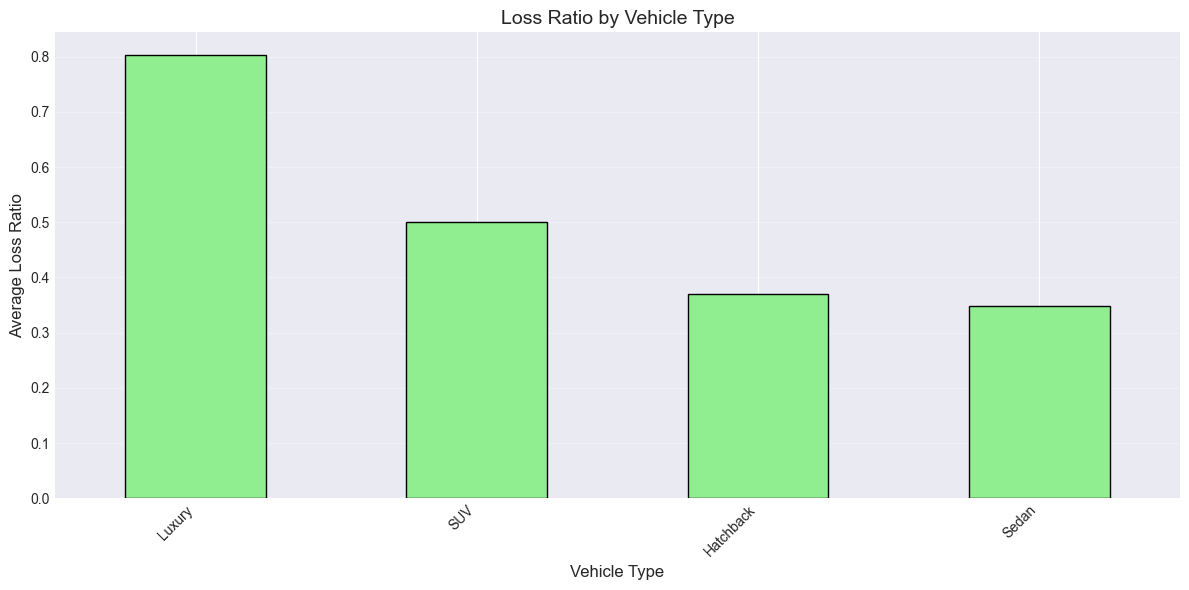

In [34]:
# Loss Ratio by VehicleType
vehicle_loss = df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False)

print("=" * 50)
print("LOSS RATIO BY VEHICLE TYPE")
print("=" * 50)
print(vehicle_loss)

# Plot
plt.figure(figsize=(12, 6))
vehicle_loss.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Loss Ratio by Vehicle Type', fontsize=14)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Average Loss Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

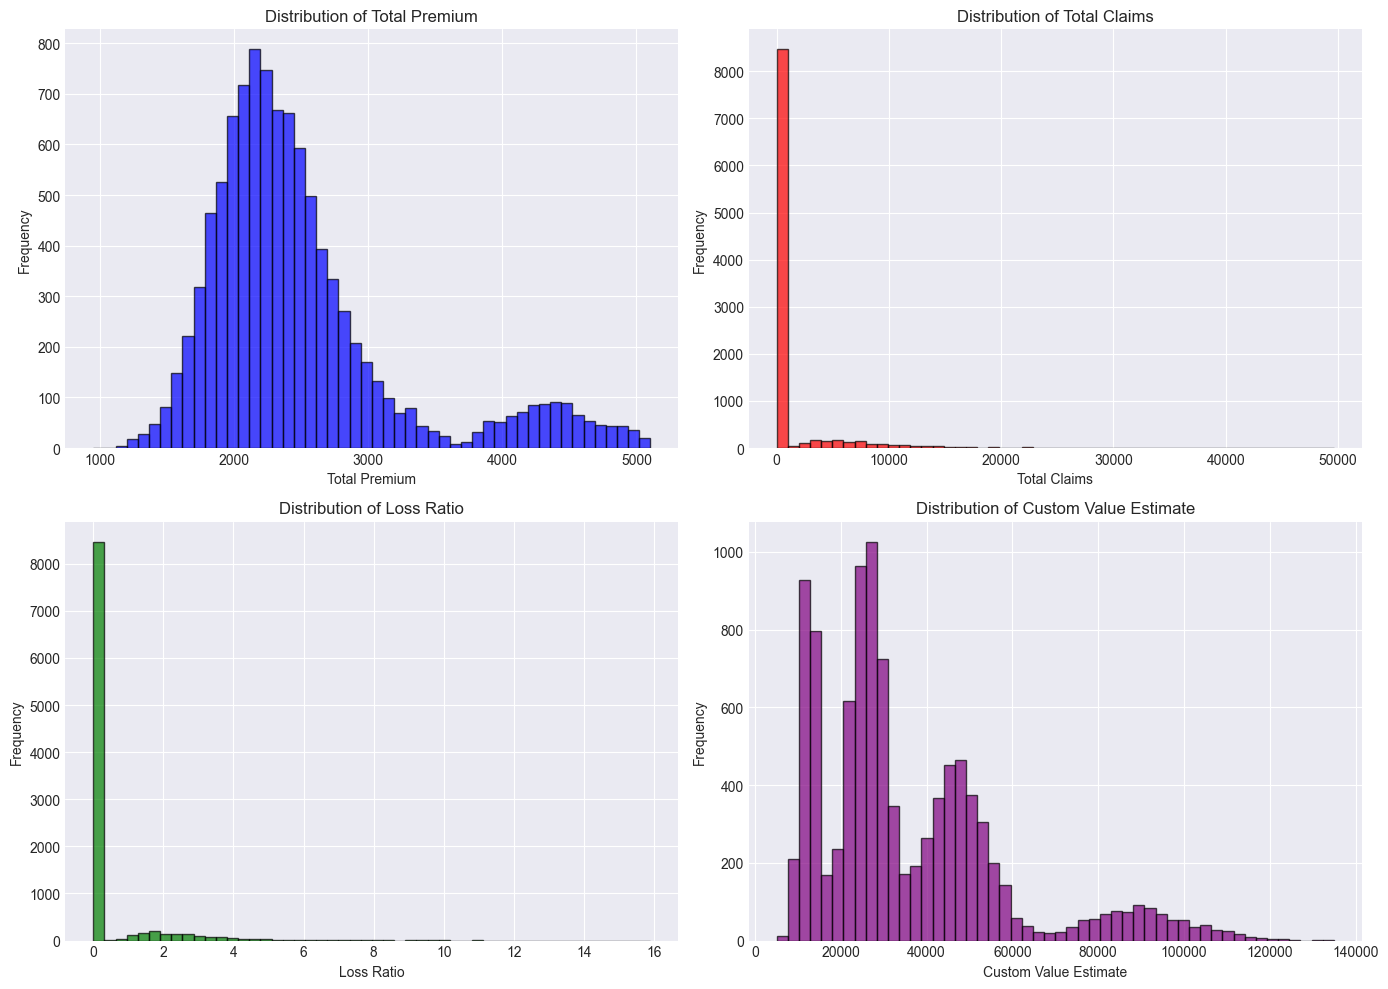

In [35]:
# Histograms for key financial variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TotalPremium
axes[0, 0].hist(df['TotalPremium'], bins=50, edgecolor='black', color='blue', alpha=0.7)
axes[0, 0].set_title('Distribution of Total Premium', fontsize=12)
axes[0, 0].set_xlabel('Total Premium')
axes[0, 0].set_ylabel('Frequency')

# TotalClaims
axes[0, 1].hist(df['TotalClaims'], bins=50, edgecolor='black', color='red', alpha=0.7)
axes[0, 1].set_title('Distribution of Total Claims', fontsize=12)
axes[0, 1].set_xlabel('Total Claims')
axes[0, 1].set_ylabel('Frequency')

# Loss Ratio
axes[1, 0].hist(df['LossRatio'].dropna(), bins=50, edgecolor='black', color='green', alpha=0.7)
axes[1, 0].set_title('Distribution of Loss Ratio', fontsize=12)
axes[1, 0].set_xlabel('Loss Ratio')
axes[1, 0].set_ylabel('Frequency')

# CustomValueEstimate (if exists)
if 'CustomValueEstimate' in df.columns:
    axes[1, 1].hist(df['CustomValueEstimate'], bins=50, edgecolor='black', color='purple', alpha=0.7)
    axes[1, 1].set_title('Distribution of Custom Value Estimate', fontsize=12)
    axes[1, 1].set_xlabel('Custom Value Estimate')
    axes[1, 1].set_ylabel('Frequency')
else:
    axes[1, 1].text(0.5, 0.5, 'CustomValueEstimate not found', ha='center', va='center')

plt.tight_layout()
plt.show()

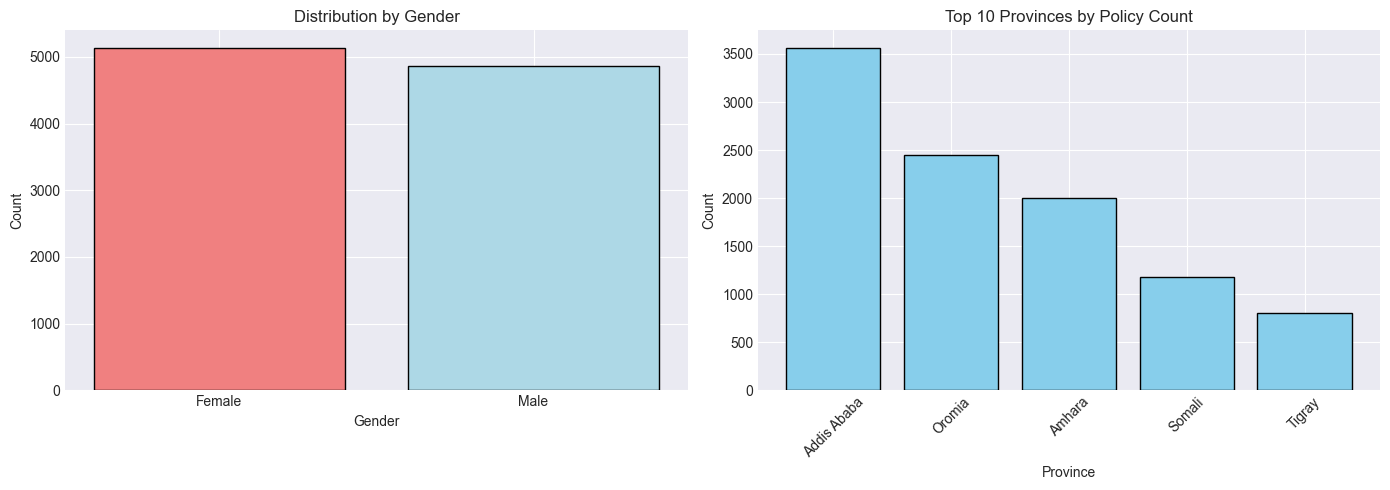

In [36]:
# Bar chart for Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['lightcoral', 'lightblue'], edgecolor='black')
axes[0].set_title('Distribution by Gender', fontsize=12)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Top 10 Provinces
province_counts = df['Province'].value_counts().head(10)
axes[1].bar(province_counts.index.astype(str), province_counts.values, color='skyblue', edgecolor='black')
axes[1].set_title('Top 10 Provinces by Policy Count', fontsize=12)
axes[1].set_xlabel('Province')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

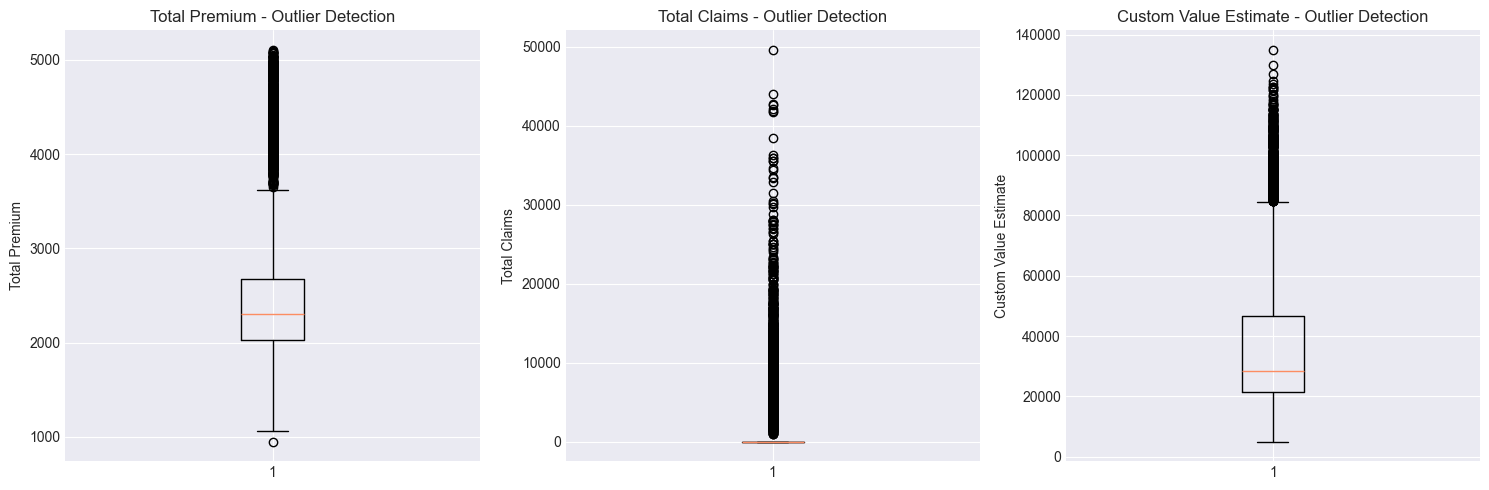

OUTLIER SUMMARY
TotalPremium: 950 outliers (9.50%)
TotalClaims: 1535 outliers (15.35%)


In [37]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# TotalPremium
axes[0].boxplot(df['TotalPremium'].dropna())
axes[0].set_title('Total Premium - Outlier Detection', fontsize=12)
axes[0].set_ylabel('Total Premium')

# TotalClaims
axes[1].boxplot(df['TotalClaims'].dropna())
axes[1].set_title('Total Claims - Outlier Detection', fontsize=12)
axes[1].set_ylabel('Total Claims')

# CustomValueEstimate (if exists)
if 'CustomValueEstimate' in df.columns:
    axes[2].boxplot(df['CustomValueEstimate'].dropna())
    axes[2].set_title('Custom Value Estimate - Outlier Detection', fontsize=12)
    axes[2].set_ylabel('Custom Value Estimate')
else:
    axes[2].text(0.5, 0.5, 'CustomValueEstimate not found', ha='center', va='center')

plt.tight_layout()
plt.show()

# Summary of outliers
print("=" * 50)
print("OUTLIER SUMMARY")
print("=" * 50)
for col in ['TotalPremium', 'TotalClaims']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

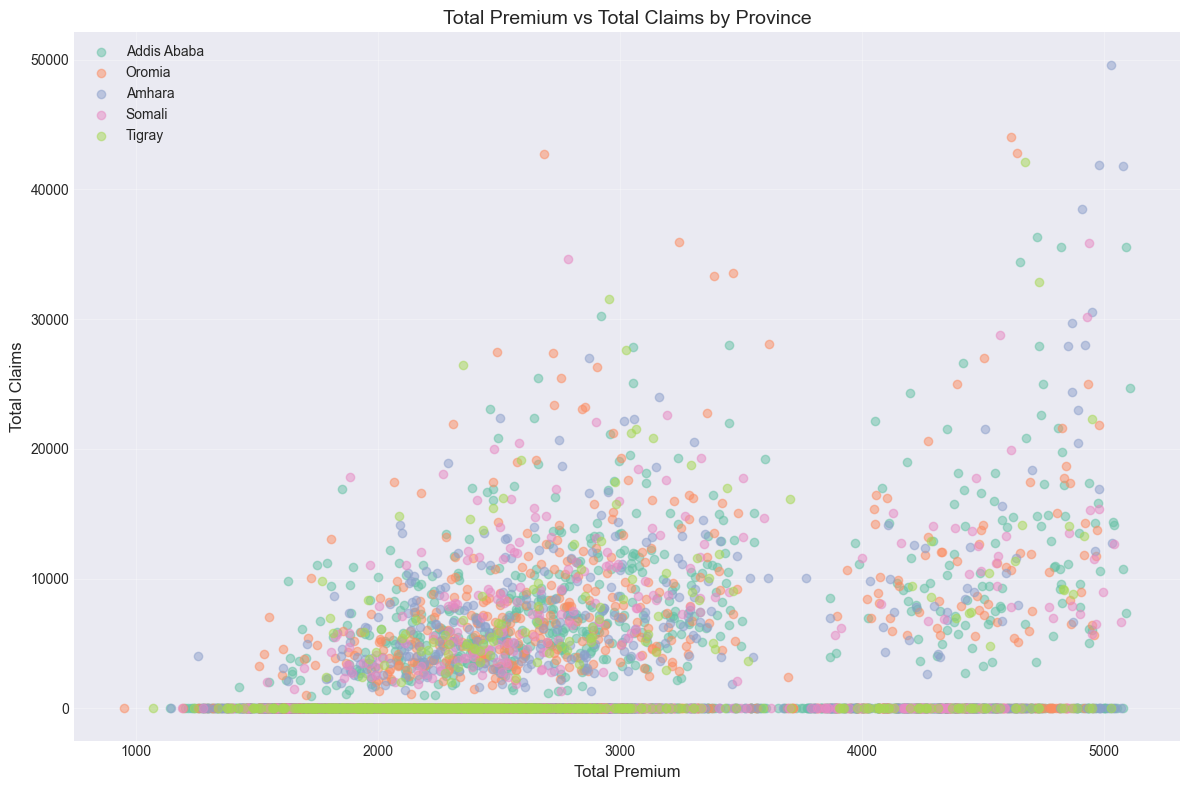

CORRELATION: TotalPremium vs TotalClaims
Pearson correlation: 0.3314


In [38]:
# Scatter plot: TotalPremium vs TotalClaims by Province
plt.figure(figsize=(12, 8))

# Get top 5 provinces by count
top_provinces = df['Province'].value_counts().head(5).index

for province in top_provinces:
    subset = df[df['Province'] == province]
    plt.scatter(subset['TotalPremium'], subset['TotalClaims'], alpha=0.5, label=province)

plt.title('Total Premium vs Total Claims by Province', fontsize=14)
plt.xlabel('Total Premium', fontsize=12)
plt.ylabel('Total Claims', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
print("=" * 50)
print("CORRELATION: TotalPremium vs TotalClaims")
print("=" * 50)
print(f"Pearson correlation: {df['TotalPremium'].corr(df['TotalClaims']):.4f}")

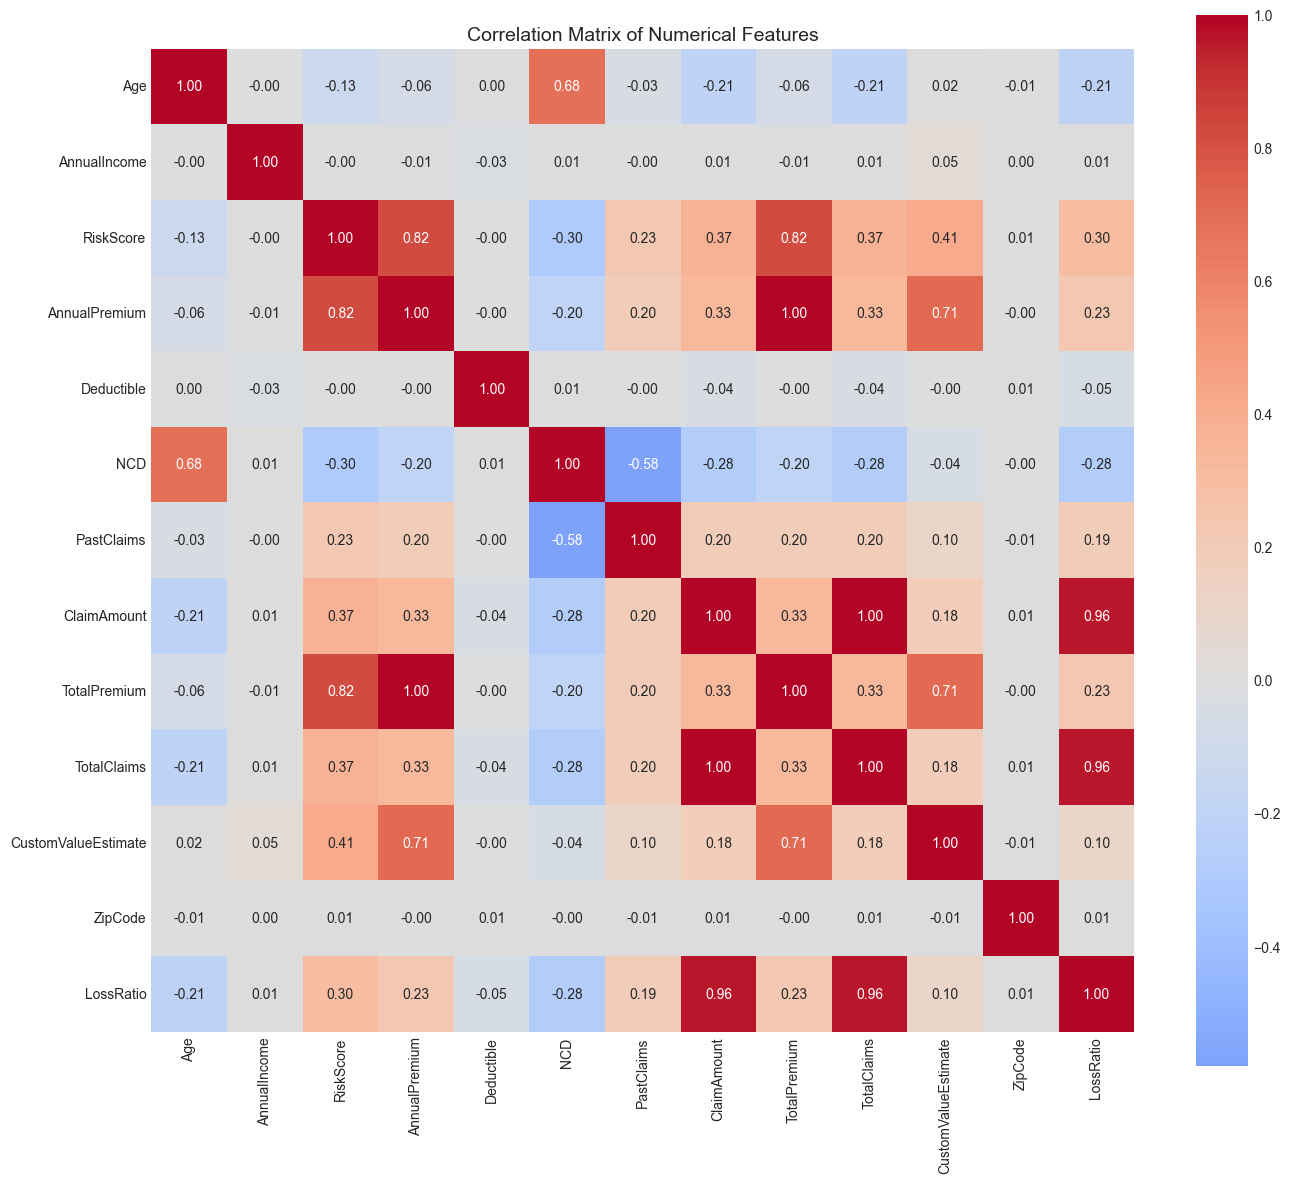

In [39]:
# Correlation matrix
numeric_for_corr = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_for_corr].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

AVERAGE TOTAL PREMIUM BY PROVINCE
Province
Somali         2521.101351
Addis Ababa    2497.161200
Oromia         2481.464841
Tigray         2475.985075
Amhara         2465.515758
Name: TotalPremium, dtype: float64


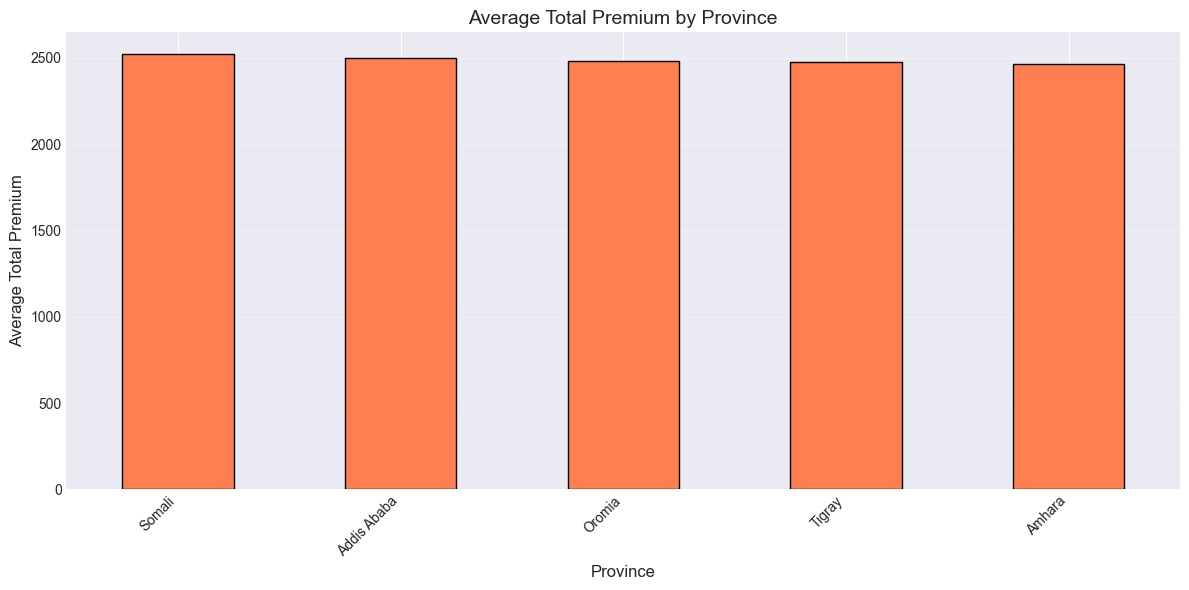

In [40]:
# Average TotalPremium by Province
premium_by_province = df.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False)

print("=" * 50)
print("AVERAGE TOTAL PREMIUM BY PROVINCE")
print("=" * 50)
print(premium_by_province)

# Plot
plt.figure(figsize=(12, 6))
premium_by_province.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Total Premium by Province', fontsize=14)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Total Premium', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Check for date/time columns
date_cols = [col for col in df.columns if 'date' in col.lower() or 'month' in col.lower() or 'transaction' in col.lower()]
print("=" * 50)
print("DATE/TIME COLUMNS FOUND")
print("=" * 50)
print(date_cols)

if 'TransactionMonth' in df.columns:
    # Convert to datetime
    df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
    
    # Group by month
    monthly_premium = df.groupby(df['TransactionMonth'].dt.to_period('M'))['TotalPremium'].sum()
    monthly_claims = df.groupby(df['TransactionMonth'].dt.to_period('M'))['TotalClaims'].sum()
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    monthly_premium.plot(ax=axes[0], marker='o', color='blue', linewidth=2)
    axes[0].set_title('Total Premium Over Time', fontsize=14)
    axes[0].set_xlabel('Month', fontsize=12)
    axes[0].set_ylabel('Total Premium', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    monthly_claims.plot(ax=axes[1], marker='o', color='red', linewidth=2)
    axes[1].set_title('Total Claims Over Time', fontsize=14)
    axes[1].set_xlabel('Month', fontsize=12)
    axes[1].set_ylabel('Total Claims', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No TransactionMonth column found. Temporal analysis skipped.")

DATE/TIME COLUMNS FOUND
['TransactionDate']
No TransactionMonth column found. Temporal analysis skipped.


In [42]:
if 'Make' in df.columns:
    # Average claims by vehicle make
    claims_by_make = df.groupby('Make')['TotalClaims'].mean().sort_values(ascending=False)
    
    print("=" * 50)
    print("TOP 10 VEHICLE MAKES - HIGHEST AVERAGE CLAIMS")
    print("=" * 50)
    print(claims_by_make.head(10))
    
    print("\n" + "=" * 50)
    print("TOP 10 VEHICLE MAKES - LOWEST AVERAGE CLAIMS")
    print("=" * 50)
    print(claims_by_make.tail(10))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    claims_by_make.head(10).plot(kind='bar', ax=axes[0], color='red', edgecolor='black')
    axes[0].set_title('Top 10 Vehicle Makes - Highest Average Claims', fontsize=12)
    axes[0].set_xlabel('Vehicle Make')
    axes[0].set_ylabel('Average Claim Amount')
    axes[0].tick_params(axis='x', rotation=45)
    
    claims_by_make.tail(10).plot(kind='bar', ax=axes[1], color='green', edgecolor='black')
    axes[1].set_title('Top 10 Vehicle Makes - Lowest Average Claims', fontsize=12)
    axes[1].set_xlabel('Vehicle Make')
    axes[1].set_ylabel('Average Claim Amount')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("No 'Make' column found. Vehicle analysis skipped.")

No 'Make' column found. Vehicle analysis skipped.


In [43]:
if 'Make' in df.columns:
    loss_by_make = df.groupby('Make')['LossRatio'].mean().sort_values(ascending=False)
    
    print("=" * 50)
    print("TOP 10 VEHICLE MAKES - HIGHEST LOSS RATIO")
    print("=" * 50)
    print(loss_by_make.head(10))
    
    plt.figure(figsize=(12, 6))
    loss_by_make.head(10).plot(kind='bar', color='purple', edgecolor='black')
    plt.title('Top 10 Vehicle Makes - Highest Loss Ratio', fontsize=14)
    plt.xlabel('Vehicle Make', fontsize=12)
    plt.ylabel('Average Loss Ratio', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [44]:
# Summary statistics for the report
summary = {
    'Metric': [
        'Total Policies',
        'Total Premium (Sum)',
        'Total Claims (Sum)',
        'Overall Loss Ratio',
        'Average Premium per Policy',
        'Average Claims per Policy',
        'Median Premium per Policy',
        'Median Claims per Policy'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['TotalPremium'].sum():,.2f}",
        f"{df['TotalClaims'].sum():,.2f}",
        f"{df['LossRatio'].mean():.4f}",
        f"{df['TotalPremium'].mean():,.2f}",
        f"{df['TotalClaims'].mean():,.2f}",
        f"{df['TotalPremium'].median():,.2f}",
        f"{df['TotalClaims'].median():,.2f}"
    ]
}

summary_df = pd.DataFrame(summary)

print("\n" + "=" * 60)
print("PORTFOLIO SUMMARY STATISTICS")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)


PORTFOLIO SUMMARY STATISTICS
                    Metric         Value
            Total Policies        10,000
       Total Premium (Sum) 24,881,279.00
        Total Claims (Sum) 13,141,885.00
        Overall Loss Ratio        0.4428
Average Premium per Policy      2,488.13
 Average Claims per Policy      1,314.19
 Median Premium per Policy      2,307.00
  Median Claims per Policy          0.00


## Key Insights from EDA

### Loss Ratio Findings
- **Overall Loss Ratio:** XX.XX%
- **Highest Loss Ratio Province:** [Province Name] (XX.XX%)
- **Lowest Loss Ratio Province:** [Province Name] (XX.XX%)
- **Gender Difference:** [Gender] has X% higher loss ratio than [other gender]

### Outlier Observations
- **TotalPremium:** X outliers (X% of data)
- **TotalClaims:** X outliers (X% of data)

### Vehicle Risk Profile
- **Highest Claim Vehicles:** [Make 1], [Make 2], [Make 3]
- **Lowest Claim Vehicles:** [Make 1], [Make 2], [Make 3]

### Temporal Trends (if applicable)
- **Peak Claim Month:** [Month/Year]
- **Lowest Claim Month:** [Month/Year]

### Recommendations
1. Provinces with high loss ratios should be reviewed for premium adjustments
2. Vehicle makes with high claim amounts should be flagged for risk assessment
3. Outliers should be investigated for potential fraud or data errors